In [ ]:
# !pip install -U keras
# !pip install -q tensorflow_datasets
# !pip install -q -U tensorflow-text tensorflow
!pip install imagecodecs
!pip install patchify


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 18.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import PIL
from PIL import Image

import math


from tensorflow.keras.utils import Sequence

import imagecodecs
from glob import glob
from sklearn.model_selection import train_test_split
from patchify import patchify

In [ ]:
## define directories ##
first_image_dir = '/content/drive/MyDrive/split_images/first_image'
mask_dir = '/content/drive/MyDrive/split_images/masks/80_masks/'
last_image_dir = '/content/drive/MyDrive/split_images/last_image'
loss_dir = '/content/drive/MyDrive/split_images/loss_images/'

# img_height = 400
# img_width = 400

In [ ]:
## set configurations and hyperparameters


batch_size = 8
img_size = 400
num_channels = 3
NUM_LAYERS = 12
HIDDEN_DIM = 400

NUM_HEADS = 6
DROPOUT = 0.1
PATCH_SIZE = 16
NUM_PATCHES = (img_size*img_size) // (PATCH_SIZE*PATCH_SIZE)
TOTAL_PATCHES_SHAPE = (NUM_PATCHES, PATCH_SIZE*PATCH_SIZE*num_channels)


CONTRAST_FACTOR = 3
DELTA = 0.3

In [ ]:
def load_dataset(path, split=0.1):
    """ Loading the images and masks """

    ## read in paths for true color images or preprocessed images (NDVI)
    """
    Implement focused training approach by training on original true color image first to learn core features
    and then refine model with augmented images to learn more nuanced patterns
    """
    X = sorted(glob(os.path.join(dataset_path, "first_image", "*.png")))

    # preprocessed images
    # X = sorted(glob(os.path.join(path, "preprocessed_first", "*.png")))

    ## read in paths for masks - same for true color and preprocessed
    Y = sorted(glob(os.path.join(path, "masks/80_masks", "*.png")))

    """ Spliting the data into training and testing """
    split_size = int(len(X) * split)

    train_x, valid_x = train_test_split(X, test_size=split_size, random_state=42)
    train_y, valid_y = train_test_split(Y, test_size=split_size, random_state=42)

    train_x, test_x = train_test_split(train_x, test_size=split_size, random_state=42)
    train_y, test_y = train_test_split(train_y, test_size=split_size, random_state=42)

    return (train_x, train_y), (valid_x, valid_y), (test_x, test_y)


#### Test and Apply augmentations ####
def augment_image(image):
    image = tf.image.adjust_brightness(image, delta=DELTA)
    image = tf.image.adjust_contrast(image, contrast_factor=CONTRAST_FACTOR)
    # image = tf.image.random_flip_left_right(image)
    # image = tf.image.random_flip_up_down(image)
    image = image.numpy()
    return image

def read_image(path):
    path = path.decode()
    image = cv2.imread(path, cv2.IMREAD_COLOR)
    image = cv2.resize(image, (img_size, img_size))
    image = image / 255.0
    # image = augment_image(image)

    """ Processing to patches """
    patch_shape = (PATCH_SIZE, PATCH_SIZE, num_channels)
    patches = patchify(image, patch_shape, PATCH_SIZE)
    patches = np.reshape(patches, TOTAL_PATCHES_SHAPE)
    patches = patches.astype(np.float32)

    return patches

def read_mask(path):
    path = path.decode()
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    mask[mask>1]=0
    mask = mask.astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)
    return mask

def tf_parse(x, y):
    def _parse(x, y):
        x = read_image(x)
        y = read_mask(y)
        return x, y

    x, y = tf.numpy_function(_parse, [x, y], [tf.float32, tf.float32]) # wraps a python function into tensorflow and defines datatype
    x.set_shape(TOTAL_PATCHES_SHAPE)
    y.set_shape([img_size, img_size, 1])
    return x, y

def tf_dataset(X, Y, batch=2):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    ds = ds.map(tf_parse).batch(batch).prefetch(10)
    return ds


In [ ]:
dataset_path = '/content/drive/MyDrive/split_images'
(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_dataset(dataset_path,split=0.1)

print(f"Train: \t{len(train_x)} - {len(train_y)}")
print(f"Valid: \t{len(valid_x)} - {len(valid_y)}")
print(f"Test: \t{len(test_x)} - {len(test_y)}")

train_dataset = tf_dataset(train_x, train_y, batch=batch_size)
valid_dataset = tf_dataset(valid_x, valid_y, batch=batch_size)

## Check that image and mask labels match up
print("train images match labels:", [x.split('/')[6] for x in train_x] == [x.split('/')[7] for x in train_y])
print("val images match labels:", [x.split('/')[6] for x in valid_x] == [x.split('/')[7] for x in valid_y])

Train: 	1601 - 1601
Valid: 	199 - 199
Test: 	199 - 199
train images match labels: True
val images match labels: True


In [ ]:
""" Hyperparameters """

lr = 0.0105
num_epochs = 20
model_path = os.path.join("/content/drive/MyDrive/split_images/model_info", "dual_input_model80.keras")
csv_path = os.path.join("/content/drive/MyDrive/split_images/model_info", "dual_input_log80(4).csv")


In [ ]:
from sklearn.utils import shuffle
from math import log2

import tensorflow.keras.layers as L
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.models import Model, load_model

In [ ]:
smooth = 1e-15 # added to numerator and denom of dice coefficient formula to avoid division by 0
def dice_coef(y_true, y_pred):

    # flatten vectors into 1D vectors (batch_size, total_pixels)
    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)

    # gives the number of overlapping pixels between the ground truth and predicted segmentation masks
    intersection = tf.reduce_sum(y_true * y_pred)

    # measures the overlap between two samples and ranges from 0-1
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

"""
Summary:
dice coefficient measures the similarity between two binary samples
dice loss 1- dice coefficient

"""

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

In [ ]:
### Source of UNETR Transformer research paper: https://arxiv.org/abs/2103.10504v3 ####
### Source of Model architecutre: https://github.com/nikhilroxtomar/Brain-Tumor-Segmentation-in-TensorFlow-2.0/blob/main/UNET/unet.py ####

# Define Layers

# multi-layer perception block (feed forward neural network)
# - learns patterns and relations of the input by passing through linear and non-linear representations

## comprised of two linear layers with GELU activations
## dropout layer for regularizations

def mlp(x):
    x = L.Dense(32, activation="gelu")(x)
    x = L.Dropout(DROPOUT)(x)
    x = L.Dense(HIDDEN_DIM)(x)
    x = L.Dropout(DROPOUT)(x)
    return x

# basic transformer encoder block
def transformer_encoder(x):
    skip_1 = x # input is a batch of images
    x = L.LayerNormalization()(x) # layer normalization to improve training - robustness to input size
    x = L.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=HIDDEN_DIM)(x, x)
    x = L.Add()([x, skip_1]) # element-wise addition of original input to multi-head self attention output

    skip_2 = x # save element-wise addition of input and attention layer
    x = L.LayerNormalization()(x) # normalize output
    x = mlp(x) # pass through mlp block
    x = L.Add()([x, skip_2]) # add output to element-wise addition of of multi-head self attention output and original input

    return x


"""Summary:
Layer Normalization: Stabilizes and accelerates training.
Multi-Head Attention: Allows the model to learn relationships within the input sequence or image patches.
Residual Connections: Help mitigate the vanishing gradient problem and stabilize training.
MLP Block: Introduces additional non-linear transformations and regularization."""
def conv_block(x, num_filters, kernel_size=3): # usually used to decrease the size of an input
    x = L.Conv2D(num_filters, kernel_size=kernel_size, padding="same")(x)
    # slides 3x3 filter and performs element-wise multiplication and summation to produce output tensor
    # detects features
    x = L.BatchNormalization()(x) # normalize output
    x = L.ReLU()(x) # introduce non-linearity
    return x

def deconv_block(x, num_filters, strides=2): # used to increase the size of an input
    x = L.Conv2DTranspose(num_filters, kernel_size=2, padding="same", strides=strides)(x)
    return x

def build_unetr_2d():
    """ Inputs """
    input_shape = (NUM_PATCHES, PATCH_SIZE*PATCH_SIZE*num_channels)
    inputs = L.Input(input_shape) ## (None, 625, 768)

    """ Patch + Position Embeddings """
    patch_embed = L.Dense(HIDDEN_DIM)(inputs) ## (None, 625, 768)
    # apply a dense fully connected layer to inputs

    positions = tf.range(start=0, limit=NUM_PATCHES, delta=1) ## (625,)
    # creates a 1D tensor of positions ranging from 0 to 256-1
    pos_embed = L.Embedding(input_dim=NUM_PATCHES, output_dim=HIDDEN_DIM)(positions) ## (625, 768)
    # apply embedding layer to convert int positions into vectors of size hidden_dim
    x = patch_embed + pos_embed ## (None, 256, 768)
    # add path embedding to pos_embedding

    ## sets up initial embeddings for patch-based processing in later layers
    """ Transformer Encoder """
    skip_connection_index = [3, 6, 9, 12] # define indices of layers where skip connections will be applied
    skip_connections = []

    for i in range(1, NUM_LAYERS+1, 1):
        x = transformer_encoder(x)

        if i in skip_connection_index:
            skip_connections.append(x)

    # if layer has skip connection - save it

    """ CNN Decoder """
    z3, z6, z9, z12 = skip_connections # save skip connection output

    ## Reshaping
    z0 = L.Reshape((img_size, img_size, num_channels))(inputs)

    shape = (
        img_size//PATCH_SIZE,
        img_size//PATCH_SIZE,
        HIDDEN_DIM
    )
    z3 = L.Reshape(shape)(z3)
    z6 = L.Reshape(shape)(z6)
    z9 = L.Reshape(shape)(z9)
    z12 = L.Reshape(shape)(z12) # reshape output from skip connections - allows them to concatenated to output from CNN Decoder

    # high resolution: having more spatial details representaed by a greater number of smaller patches

    ## Additional layers for managing different patch sizes
    total_upscale_factor = int(log2(PATCH_SIZE))
    upscale = total_upscale_factor - 4

    if upscale >= 2: ## Patch size 16 or greater - exapand patches
        z3 = deconv_block(z3, z3.shape[-1], strides=2**upscale)
        z6 = deconv_block(z6, z6.shape[-1], strides=2**upscale)
        z9 = deconv_block(z9, z9.shape[-1], strides=2**upscale)
        z12 = deconv_block(z12, z12.shape[-1], strides=2**upscale)
        # print(z3.shape, z6.shape, z9.shape, z12.shape)

    if upscale < 0: ## Patch size less than 16
        p = 2**abs(upscale)
        z3 = L.MaxPool2D((p, p))(z3)
        z6 = L.MaxPool2D((p, p))(z6)
        z9 = L.MaxPool2D((p, p))(z9)
        z12 = L.MaxPool2D((p, p))(z12)

    ## Decoder 1
    x = deconv_block(z12, 128) # up sample most abstract representation to a higher resolution

    s = deconv_block(z9, 128) # upsample to higher resolution
    s = conv_block(s, 128) # refine with convolutional layer

    x = L.Concatenate()([x, s]) # merge upsamples z12 and processed z9

    x = conv_block(x, 128) # apply two convolutional blocks to the combined feature maps
    x = conv_block(x, 128)

    ## Decoder 2
    x = deconv_block(x, 64) # continue to expand to a higher resolution

    s = deconv_block(z6, 64) # upsample z6 to current resolution
    s = conv_block(s, 64) # refine with filter
    s = deconv_block(s, 64) # upsample refined z6 to current resolution
    s = conv_block(s, 64) # refine with filter

    x = L.Concatenate()([x, s]) # concatenate other patches and refine
    x = conv_block(x, 64) # refine
    x = conv_block(x, 64) # refine

    ## Decoder 3
    x = deconv_block(x, 32)  # upsample results

    s = deconv_block(z3, 32) # upsample z3 to current resolution 3 times
    s = conv_block(s, 32)
    s = deconv_block(s, 32)
    s = conv_block(s, 32)
    s = deconv_block(s, 32)
    s = conv_block(s, 32)

    x = L.Concatenate()([x, s]) # concat results and refined z3
    x = conv_block(x, 32) # refine
    x = conv_block(x, 32) # refine

    ## Decoder 4
    x = deconv_block(x, 16) # upsample results to higher resolution

    s = conv_block(z0, 16) # refine original input
    s = conv_block(s, 16) # refine

    x = L.Concatenate()([x, s]) # concatenate results and refined original input
    x = conv_block(x, 16)
    x = conv_block(x, 16)

    """ Output """
    outputs = L.Conv2D(1, kernel_size=1, padding="same", activation="sigmoid")(x)

    # 1 filter is applied to produce single-output channel
    # 1x1 kernel
    #

    return Model(inputs, outputs, name="UNETR_2D")


""" Model """
### Build or Load Model ###

# model = build_unetr_2d()
model = load_model(model_path, custom_objects={'dice_loss':dice_loss,
                                               'dice_coef':dice_coef,
                                               'bce_dice_loss':bce_dice_loss})


In [ ]:
# model.summary()

In [ ]:
### Compile and Train Model ###



model.compile(loss=[dice_loss,bce_dice_loss], optimizer=SGD(lr), metrics=[tf.keras.metrics.BinaryIoU(target_class_ids=(0, 1), threshold=0.5, name='IoU'),
                                                          tf.keras.metrics.Precision(thresholds=0.5,name='precision'),
                                                          tf.keras.metrics.Recall(thresholds=0.5,name='recall'),
                                                          dice_coef, "acc"])


callbacks = [
    ModelCheckpoint(model_path, verbose=1, save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger(csv_path),
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=False)
]

model.fit(
    train_dataset,
    epochs=num_epochs,
    validation_data=valid_dataset,
    callbacks=callbacks
)

Epoch 1/20
201/201 [==============================] - ETA: 0s - loss: 0.1248 - IoU: 0.8423 - precision: 0.8661 - recall: 0.9108 - dice_coef: 0.8719 - acc: 0.9216
Epoch 1: val_loss improved from inf to 0.12962, saving model to /content/drive/MyDrive/split_images/model_info/dual_input_model80.keras
201/201 [==============================] - 320s 1s/step - loss: 0.1248 - IoU: 0.8423 - precision: 0.8661 - recall: 0.9108 - dice_coef: 0.8719 - acc: 0.9216 - val_loss: 0.1296 - val_IoU: 0.8266 - val_precision: 0.8267 - val_recall: 0.9333 - val_dice_coef: 0.8703 - val_acc: 0.9124 - lr: 0.0105
Epoch 2/20
201/201 [==============================] - ETA: 0s - loss: 0.1245 - IoU: 0.8426 - precision: 0.8663 - recall: 0.9110 - dice_coef: 0.8722 - acc: 0.9217
Epoch 2: val_loss did not improve from 0.12962
201/201 [==============================] - 284s 1s/step - loss: 0.1245 - IoU: 0.8426 - precision: 0.8663 - recall: 0.9110 - dice_coef: 0.8722 - acc: 0.9217 - val_loss: 0.1299 - val_IoU: 0.8258 - val_p

In [ ]:
### save test image,mask,predictions in list of tuples ###
### use to visualize and compare results ###

result = []
for i in range(3):
  x = test_x[i]
  y = test_y[i]

  """ Reading the image """
  image = cv2.imread(x, cv2.IMREAD_COLOR)
  image = cv2.resize(image, (img_size, img_size))
  x = image / 255.0

  patch_shape = (PATCH_SIZE, PATCH_SIZE, num_channels)
  patches = patchify(x, patch_shape, PATCH_SIZE)
  patches = np.reshape(patches, TOTAL_PATCHES_SHAPE)
  patches = patches.astype(np.float32)
  patches = np.expand_dims(patches, axis=0)

  """ Read Mask """
  mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)
  # mask = cv2.resize(mask, (img_size, img_size))
  mask[mask>1] = 0
  mask = np.expand_dims(mask, axis=-1)
  # mask = np.concatenate([mask, mask, mask], axis=-1)

  """ Prediction """
  pred = model.predict(patches, verbose=0)[0]

  result.append((image,mask,pred))

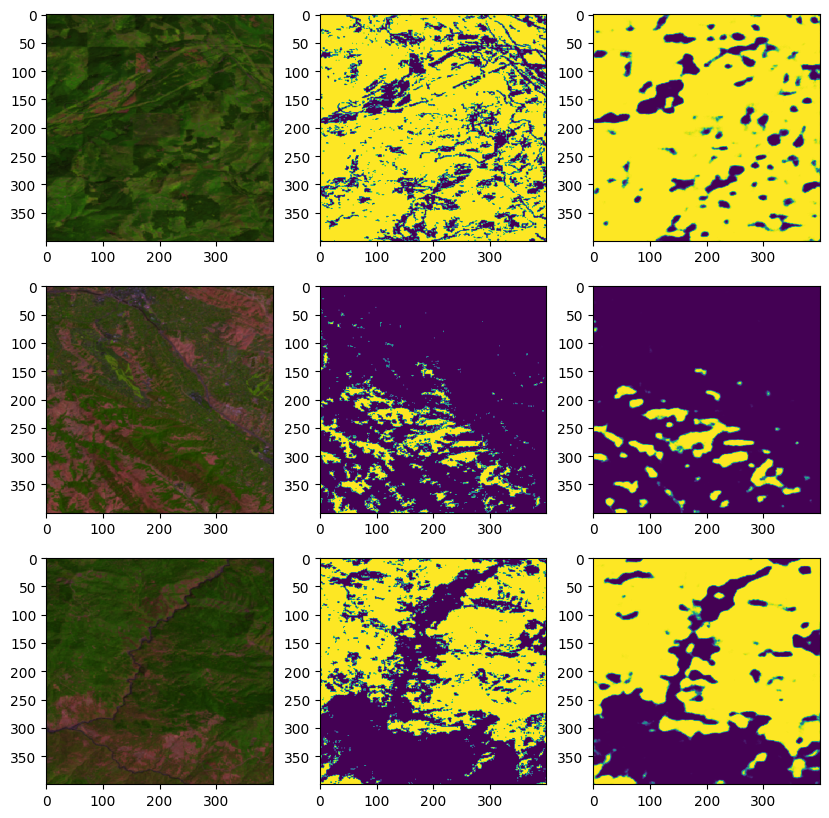

In [ ]:
fig,axs = plt.subplots(3,3,figsize=(10,10))
axs[0,0].imshow(result[0][0])
axs[0,1].imshow(result[0][1])
axs[0,2].imshow(result[0][2])

axs[1,0].imshow(result[1][0])
axs[1,1].imshow(result[1][1])
axs[1,2].imshow(result[1][2])

axs[2,0].imshow(result[2][0])
axs[2,1].imshow(result[2][1])
axs[2,2].imshow(result[2][2])

In [ ]:
# input image from 2023
x = ('/content/drive/MyDrive/split_images/last_image/50N_19_98.png')
image = cv2.imread(x, cv2.IMREAD_COLOR)
image = cv2.resize(image, (img_size, img_size))
x = image / 255.0

patch_shape = (PATCH_SIZE, PATCH_SIZE, num_channels)
patches = patchify(x, patch_shape, PATCH_SIZE)
patches = np.reshape(patches, TOTAL_PATCHES_SHAPE)
patches = patches.astype(np.float32)
patches = np.expand_dims(patches, axis=0)

""" Prediction """
pred_2023 = model.predict(patches, verbose=0)[0]

In [ ]:
# input corresponding image from 2000
x = ('/content/drive/MyDrive/split_images/first_image/50N_19_98.png')
image = cv2.imread(x, cv2.IMREAD_COLOR)
image = cv2.resize(image, (img_size, img_size))
x = image / 255.0

patch_shape = (PATCH_SIZE, PATCH_SIZE, num_channels)
patches = patchify(x, patch_shape, PATCH_SIZE)
patches = np.reshape(patches, TOTAL_PATCHES_SHAPE)
patches = patches.astype(np.float32)
patches = np.expand_dims(patches, axis=0)

""" Prediction """
pred_2000 = model.predict(patches, verbose=0)[0]

In [ ]:

pred_2000_array = np.array(pred_2000[:,:,0].round())
pred_2023_array = np.array(pred_2023[:,:,0].round())

pred_loss = pred_2000_array - pred_2023_array
pred_loss[pred_loss < 1 ] = 0


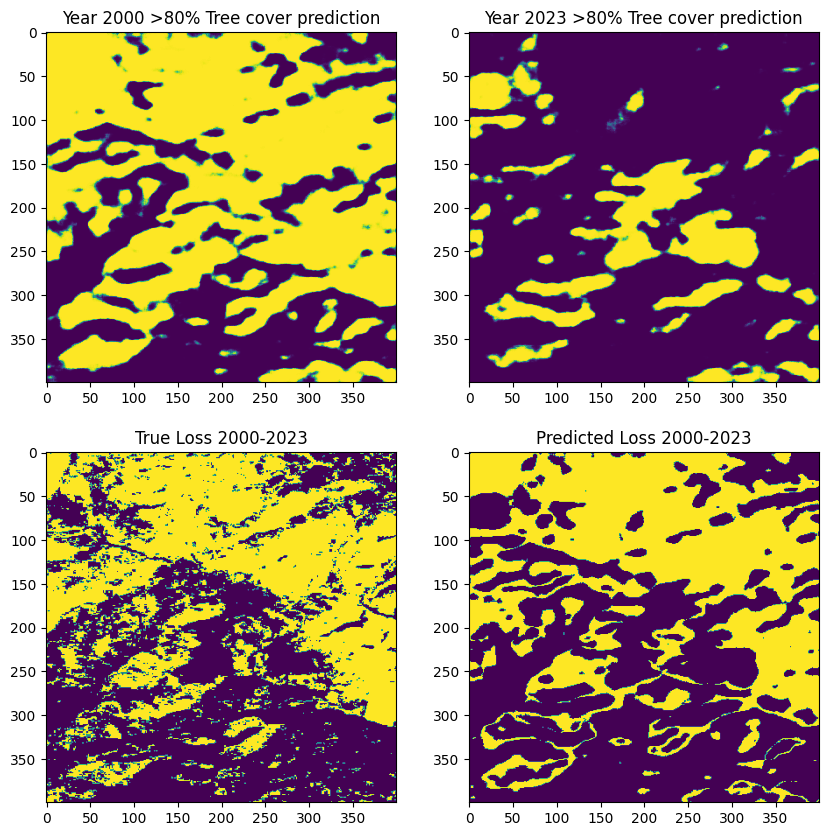

In [ ]:
loss_img = Image.open('/content/drive/MyDrive/split_images/loss_images/50N_19_98.png')
loss_img = np.array(loss_img)
loss_img[loss_img >0] = 1

fig,axs = plt.subplots(2,2,figsize=(10,10))
axs[0,0].imshow(pred_2000)
axs[0,0].set_title('Year 2000 >80% Tree cover prediction')
axs[0,1].imshow(pred_2023)
axs[0,1].set_title('Year 2023 >80% Tree cover prediction')
axs[1,0].imshow(loss_img)
axs[1,0].set_title('True Loss 2000-2023')
axs[1,1].imshow(pred_loss)
axs[1,1].set_title('Predicted Loss 2000-2023')

plt.show()

In [ ]:
(pred_loss == np.array(loss_img)).mean()

0.76909375

In [ ]:
log80 = pd.read_csv('/content/drive/MyDrive/split_images/model_info/dual_input_log80.csv')
log80_2 = pd.read_csv('/content/drive/MyDrive/split_images/model_info/dual_input_log80(1).csv')
log80_3 = pd.read_csv('/content/drive/MyDrive/split_images/model_info/dual_input_log80(2).csv')
log80_4 = pd.read_csv('/content/drive/MyDrive/split_images/model_info/dual_input_log80(3).csv')
log80_5 = pd.read_csv('/content/drive/MyDrive/split_images/model_info/dual_input_log80(4).csv')
logs = pd.concat([log80,log80_2,log80_3,log80_4,log80_5])

In [ ]:
logs['epoch'] = np.arange(len(logs))

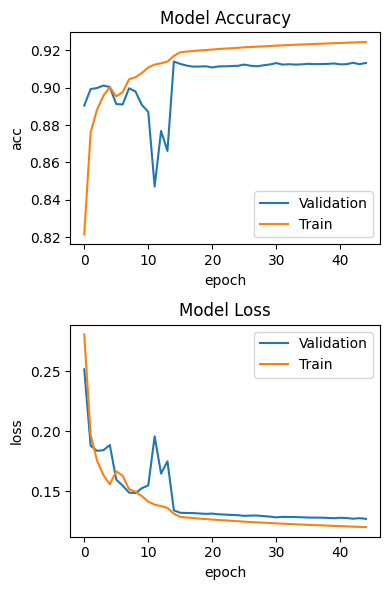

In [ ]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(4,6))

ax1.plot(logs['epoch'],logs['val_acc'])
ax1.plot(logs['epoch'],logs['acc'])
ax1.set_title('Model Accuracy')
ax1.set_xlabel('epoch')
ax1.set_ylabel('acc')
ax1.legend(['Validation','Train'], loc='lower right')

ax2.plot(logs['epoch'],logs['val_loss'])
ax2.plot(logs['epoch'],logs['loss'])
ax2.set_title('Model Loss')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend(['Validation','Train'], loc='upper right')

fig.tight_layout()
plt.show()

In [ ]:
## the jumping in the plot is from breaks in training - epochs finish and training resumes with shuffled inputs